# Эксперимент 3.4 — чувствительность и сравнения

1. **ISTA vs FISTA** — $\log(F-F^*)$ по итерациям на одной регрессионной задаче.  
2. **Frank–Wolfe**: классический шаг $\gamma_k=(k-1)/(k+1)$ vs **Armijo** — по кумулятивным вызовам оракула.  
3. **Барьер**: $\mu \in \{2,10,50,100\}$ — суммарное число внутренних ньютоновских итераций vs $\mu$.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents][:12]:
        if (p / "src" / "optimization.py").is_file():
            return p
    return here


ROOT = _find_repo_root()
sys.path.insert(0, str(ROOT))

from src.counted_oracle import CountedCompositeOracle, CountedSmoothOracle
from src.experiment_utils import synthetic_regression, tune_lambda_for_zero_fraction, radius_from_reference
from src.oracles import RegressionProxOracle
from src.optimization import (
    barrier_method,
    frank_wolfe_method,
    proximal_fast_gradient_method,
    proximal_gradient_method,
)
from src.paths import figs_dir

FIG = figs_dir()
rng = np.random.default_rng(21)
m, n = 100, 32
A, b, _ = synthetic_regression(m, n, rng)
x0 = np.zeros(n)


def build(lam):
    return RegressionProxOracle(A, b, lam, 0.0)


lam, xref = tune_lambda_for_zero_fraction(build, n, x0, max_iter_fista=3000)
R = radius_from_reference(xref, 1.03)
comp_unc = build(lam)
x_star, _, _ = proximal_fast_gradient_method(
    CountedCompositeOracle(build(lam)), x0, max_iter=12_000, tolerance=1e-11, trace=False
)
F_star = float(comp_unc.func(x_star))
print("λ", lam, "F*", F_star, "R", R)


def logg(Fs):
    return np.log10(np.maximum(np.asarray(Fs, float) - F_star, 1e-14))

λ 0.0158113883008419 F* 0.2655230639119241 R 0.3291331405636437


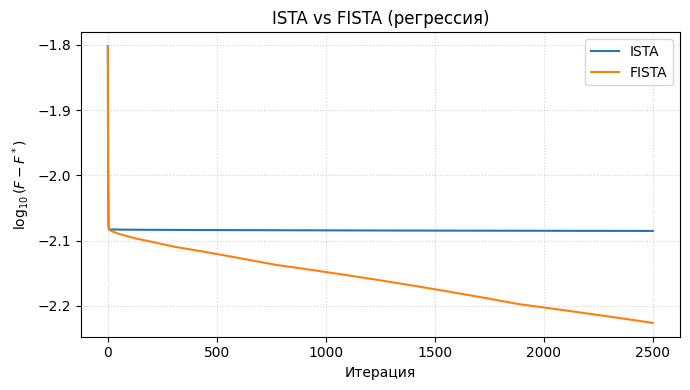

In [2]:
comp = CountedCompositeOracle(build(lam))
_, _, h_ista = proximal_gradient_method(comp, x0, max_iter=2500, tolerance=1e-14, trace=True)
comp2 = CountedCompositeOracle(build(lam))
_, _, h_fista = proximal_fast_gradient_method(comp2, x0, max_iter=2500, tolerance=1e-14, trace=True)

plt.figure(figsize=(7, 4))
plt.plot(logg(h_ista["F"]), label="ISTA")
plt.plot(logg(h_fista["F"]), label="FISTA")
plt.xlabel("Итерация")
plt.ylabel(r"$\log_{10}(F-F^*)$")
plt.title("ISTA vs FISTA (регрессия)")
plt.legend()
plt.grid(True, ls=":", alpha=0.55)
plt.tight_layout()
plt.savefig(FIG / "exp34_ista_vs_fista.png", dpi=160, bbox_inches="tight")
plt.show()

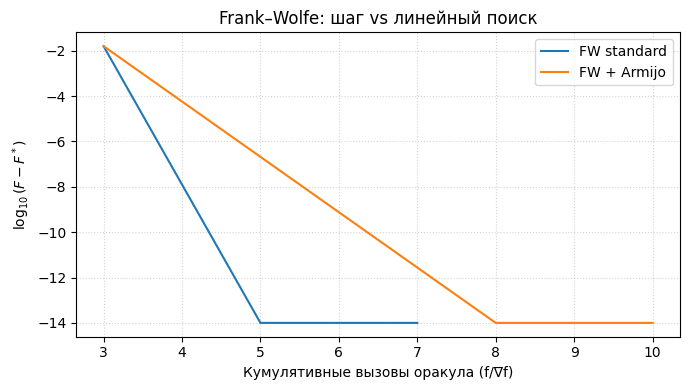

Вызовы (стандарт) последние: 7 Armijo: 10


In [3]:
sm1 = CountedSmoothOracle(build(lam).smooth)
_, _, h_fw_std = frank_wolfe_method(
    sm1, x0, R, max_iter=2000, step_size_strategy="standard", trace=True, lambda_l1=lam
)
sm2 = CountedSmoothOracle(build(lam).smooth)
_, _, h_fw_arm = frank_wolfe_method(
    sm2, x0, R, max_iter=2000, step_size_strategy="armijo", trace=True, lambda_l1=lam
)

plt.figure(figsize=(7, 4))
plt.plot(h_fw_std["oracle_calls"], logg(h_fw_std["F"]), label="FW standard")
plt.plot(h_fw_arm["oracle_calls"], logg(h_fw_arm["F"]), label="FW + Armijo")
plt.xlabel("Кумулятивные вызовы оракула (f/∇f)")
plt.ylabel(r"$\log_{10}(F-F^*)$")
plt.title("Frank–Wolfe: шаг vs линейный поиск")
plt.legend()
plt.grid(True, ls=":", alpha=0.55)
plt.tight_layout()
plt.savefig(FIG / "exp34_fw_step_vs_armijo.png", dpi=160, bbox_inches="tight")
plt.show()
print("Вызовы (стандарт) последние:", h_fw_std["oracle_calls"][-1], "Armijo:", h_fw_arm["oracle_calls"][-1])

μ 2 суммарно внутр. Ньютон: 30
μ 10 суммарно внутр. Ньютон: 31
μ 50 суммарно внутр. Ньютон: 26
μ 100 суммарно внутр. Ньютон: 30


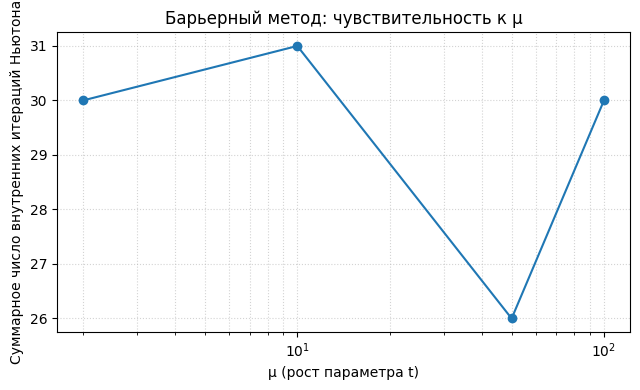

In [4]:
u0 = np.abs(x0) + 1.0
mus = [2, 10, 50, 100]
inner_sums = []
for mu in mus:
    sm = CountedSmoothOracle(build(lam).smooth)
    _, _, hb = barrier_method(
        sm,
        x0,
        u0,
        lam,
        t_0=1.0,
        mu=float(mu),
        max_iter=30,
        max_inner_iter=120,
        tolerance_inner=1e-4,
        tolerance_outer=0.25,
        trace=True,
    )
    inner_sums.append(int(np.sum(hb["inner_iters"])))
    print("μ", mu, "суммарно внутр. Ньютон:", inner_sums[-1])

plt.figure(figsize=(6.5, 4))
plt.semilogx(mus, inner_sums, marker="o")
plt.xlabel("μ (рост параметра t)")
plt.ylabel("Суммарное число внутренних итераций Ньютона")
plt.title("Барьерный метод: чувствительность к μ")
plt.grid(True, which="both", ls=":", alpha=0.55)
plt.tight_layout()
plt.savefig(FIG / "exp34_barrier_mu_vs_newton.png", dpi=160, bbox_inches="tight")
plt.show()

**Замечания.** На графике ISTA/FISTA ускоренный метод часто даёт **немонотонное** убывание по промежуточным точкам $y_k$ (инерция); по оси отложена основная последовательность $x_k$ после проксимального шага.  
FW+Armijo может снижать число итераций при той же точности, но **дороже по вызовам** `func` из-за линейного поиска.  
Слишком большой $\mu$ у барьера уменьшает число внешних шагов, но утяжеляет каждую внутреннюю задачу — оптимум по суммарным ньютоновским итерациям часто **не монотонен**.